In [7]:
# Temel
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modelleme
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression


In [8]:
# WDI dosyalarını oku
wdi = pd.read_csv("WDICSV.csv")
countries = pd.read_csv("WDICountry.csv")
series = pd.read_csv("WDISeries.csv")

# Veri yapısını incele
print(wdi.head())
print(wdi['Indicator Name'].nunique(), "farklı gösterge mevcut")


                  Country Name Country Code  \
0  Africa Eastern and Southern          AFE   
1  Africa Eastern and Southern          AFE   
2  Africa Eastern and Southern          AFE   
3  Africa Eastern and Southern          AFE   
4  Africa Eastern and Southern          AFE   

                                      Indicator Name     Indicator Code  1960  \
0  Access to clean fuels and technologies for coo...     EG.CFT.ACCS.ZS   NaN   
1  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.RU.ZS   NaN   
2  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.UR.ZS   NaN   
3            Access to electricity (% of population)     EG.ELC.ACCS.ZS   NaN   
4  Access to electricity, rural (% of rural popul...  EG.ELC.ACCS.RU.ZS   NaN   

   1961  1962  1963  1964  1965  1966  1967  1968  1969  1970  1971  1972  \
0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

In [21]:
wdi[wdi['Indicator Name'].str.contains("health|CO2", case=False, na=False)]['Indicator Name'].unique()


array(['ARI treatment (% of children under 5 taken to a health provider)',
       'Births attended by skilled health staff (% of total)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)',
       'Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)',
       'Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)',
       'Carbon dioxide (CO2) emissions from Agriculture (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Building (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Fugitive Emissions (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Industrial Combustion (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Industrial Processes (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Power Industry (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Transport (Energy) (Mt CO2e)',
       'Carbon dioxide (CO2) emissions from Waste (Mt CO2e)',
       

In [22]:
# İlgili göstergeleri filtreleme
target_indicators = [
    "GDP per capita (current US$)",
    "GDP growth (annual %)",
    "Government expenditure on education, total (% of GDP)",
    "Current health expenditure per capita (current US$)",
    "Renewable energy consumption (% of total final energy consumption)",
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)",
    "Individuals using the Internet (% of population)"
]

subset = wdi[wdi['Indicator Name'].isin(target_indicators)]


In [23]:
# Veri yapısını kontrol et
wdi.head()


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.460922,11.785469,12.119852,12.506167,12.890712,13.324145,13.790770,14.222859,14.649063,15.151686,15.615567,16.039882,16.520602,16.953688,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.465235,3.638324,3.849663,4.058893,4.293539,4.502732,4.750627,5.016145,5.263236,5.487488,5.723223,6.003738,6.259134,6.526446,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.192270,32.592996,33.036393,33.521439,34.043536,34.461126,35.039799,35.621788,35.991596,36.472377,36.788812,37.167308,37.521893,37.849572,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.917256,19.944277,21.548647,22.493217,23.724455,23.449539,25.172482,26.795145,25.908845,26.187846,27.414954,28.909756,31.673427,31.723574,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.801258,50.668330,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.623663,NaN,NaN,9.785571,10.942222,10.440734,12.562725,12.514078,12.981138,15.549057,14.541253,16.158961,19.442860,18.775074,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.783960,35.375216,NaN


In [24]:
# Geniş formattaki yılları uzun formata çevir
wdi_long = wdi.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

# Yıl sütununu sayıya çevir
wdi_long["Year"] = pd.to_numeric(wdi_long["Year"], errors="coerce")

# Şimdi "Value" sütunu mevcut!
print(wdi_long.head())


                  Country Name Country Code  \
0  Africa Eastern and Southern          AFE   
1  Africa Eastern and Southern          AFE   
2  Africa Eastern and Southern          AFE   
3  Africa Eastern and Southern          AFE   
4  Africa Eastern and Southern          AFE   

                                      Indicator Name     Indicator Code  Year  \
0  Access to clean fuels and technologies for coo...     EG.CFT.ACCS.ZS  1960   
1  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.RU.ZS  1960   
2  Access to clean fuels and technologies for coo...  EG.CFT.ACCS.UR.ZS  1960   
3            Access to electricity (% of population)     EG.ELC.ACCS.ZS  1960   
4  Access to electricity, rural (% of rural popul...  EG.ELC.ACCS.RU.ZS  1960   

   Value  
0    NaN  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


In [25]:
# İlgili göstergeleri filtrele
subset = wdi_long[wdi_long['Indicator Name'].isin(target_indicators)]

# Pivot: her ülke ve yıl için göstergeler yan yana
pivot_df = subset.pivot_table(
    index=["Country Name", "Country Code", "Year"],
    columns="Indicator Name",
    values="Value"
).reset_index()


In [26]:
# Eksik değerleri ileri doldurma (ülke bazında)
pivot_df = pivot_df.groupby("Country Name").ffill().bfill()

# Son 20 yılı (2000–2022) seç
pivot_df = pivot_df[pivot_df["Year"] >= 2000]


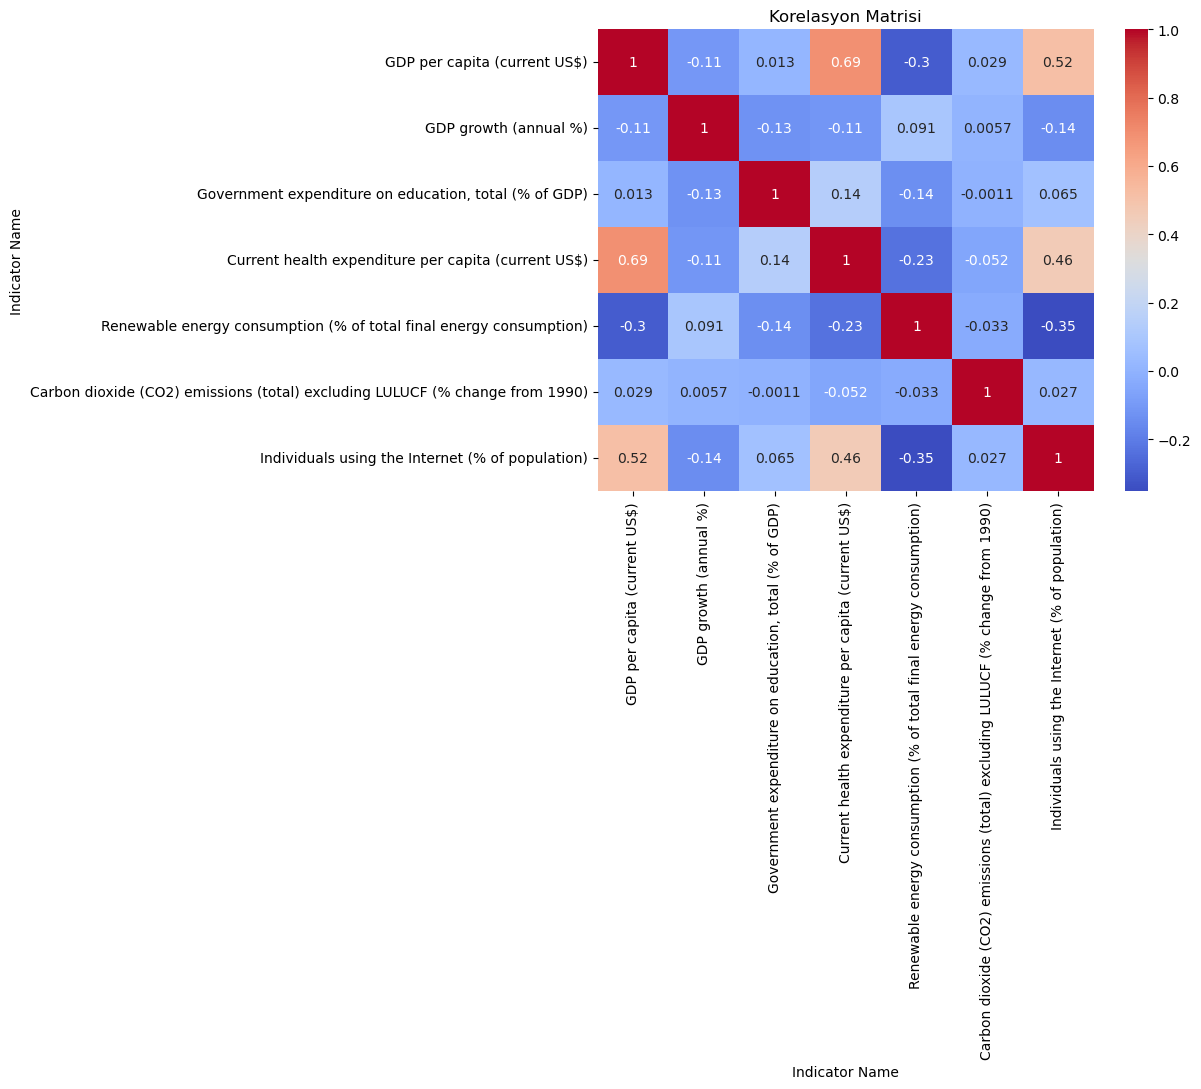

In [27]:
corr = pivot_df[target_indicators].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()


In [29]:
df = pivot_df.dropna(subset=target_indicators)
X = df[[
    "Government expenditure on education, total (% of GDP)",
    "Current health expenditure per capita (current US$)",
    "Renewable energy consumption (% of total final energy consumption)",
    "Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)",
    "Individuals using the Internet (% of population)"
]]
y = df["GDP growth (annual %)"]

model = LinearRegression()
model.fit(X, y)

coeff = pd.Series(model.coef_, index=X.columns)
print(coeff.sort_values(ascending=False))


Indicator Name
Renewable energy consumption (% of total final energy consumption)              0.005641
Carbon dioxide (CO2) emissions (total) excluding LULUCF (% change from 1990)    0.000011
Current health expenditure per capita (current US$)                            -0.000138
Individuals using the Internet (% of population)                               -0.018340
Government expenditure on education, total (% of GDP)                          -0.243467
dtype: float64
